# Анализ рынка строительства жилых и нежилых зданий (ОКВЭД 41.20)

**Задача:** собрать датасет малых и средних строительных компаний из реестра МСП ФНС, дособрать финансовую отчётность через bo.nalog.gov.ru, посчитать метрику EBITDA по годам, построить распределение роста чистой прибыли компаний и нанести топ-100 компаний по выручке на карту.


## 1. Загрузка и подготовка данных

Загружаем реестр МСП ФНС. Реальный заголовок таблицы находится на 3-й строке файла (индекс 2), первые две строки — служебные.

In [1]:
import pandas as pd

df = pd.read_excel('Реестр (1).xlsx', sheet_name='Лист1', header=2)
print(df.shape)
df.head()

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


(603520, 23)


,№ п/п,Наименование / ФИО,Тип субъекта,Категория,ОГРН,ИНН,Основной вид деятельности,Регион,Район,Город,...,Дата исключения из реестра,Телефон,E-mail,WWW,Наличие лицензий,"Наличие заключенных договоров, контрактов","Производство инновационной, высокотехнологичной продукции",Участие в программах партнерства,Является социальным предприятием,Среднесписочная численность работников за предшествующий календарный год
0,1,""" МЕГАПОЛИС "" ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВ...",Юридическое лицо,Не является субъектом МСП,1027800523376,7801190028,41.2 Строительство жилых и нежилых зданий,78 - г.Санкт-Петербург,NaN,NaN,...,10.10.2021,NaN,NaN,NaN,Нет,Нет,Нет,Нет,Нет,NaN
1,2,""" СТАЛЬИНВЕСТСТРОЙ "" ОБЩЕСТВО С ОГРАНИЧЕННОЙ О...",Юридическое лицо,Не является субъектом МСП,1037800033545,7801227976,41.20 Строительство жилых и нежилых зданий,78 - г.Санкт-Петербург,NaN,NaN,...,10.08.2018,NaN,NaN,NaN,Нет,Нет,Нет,Нет,Нет,NaN
2,3,""" СТРОЙТЕХНИКА - М "" ОБЩЕСТВО С ОГРАНИЧЕННОЙ О...",Юридическое лицо,Не является субъектом МСП,1025204418293,5263039399,41.20 Строительство жилых и нежилых зданий,52 - Нижегородская область,NaN,г Нижний Новгород,...,10.07.2022,NaN,NaN,NaN,Нет,Нет,Нет,Нет,Нет,NaN
3,4,"""БАЗИС"" ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ",Юридическое лицо,Микропредприятие,1025204411682,5263025484,41.20 Строительство жилых и нежилых зданий,52 - Нижегородская область,NaN,г Нижний Новгород,...,NaN,NaN,NaN,NaN,Нет,Нет,Нет,Нет,Нет,1.0
4,5,"""БЕЛАГ"" ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ",Юридическое лицо,Не является субъектом МСП,1037800039276,7801123215,41.20 Строительство жилых и нежилых зданий,78 - г.Санкт-Петербург,NaN,NaN,...,10.07.2021,NaN,NaN,NaN,Нет,Нет,Нет,Нет,Нет,NaN


### Разведка данных (EDA)

Перед фильтрацией смотрим на распределение значений в трёх ключевых колонках: `Тип субъекта`, `Категория`, `Основной вид деятельности`.

In [2]:
print(df['Тип субъекта'].value_counts(dropna=False))
print(df['Категория'].value_counts(dropna=False))
print(df['Основной вид деятельности'].value_counts(dropna=False))

Тип субъекта
Юридическое лицо                  402294
Индивидуальный предприниматель    201226
Name: count, dtype: int64
Категория
Не является субъектом МСП    348477
Микропредприятие             243832
Малое предприятие             10310
Среднее предприятие             901
Name: count, dtype: int64
Основной вид деятельности
41.20 Строительство жилых и нежилых зданий    530132
41.2 Строительство жилых и нежилых зданий      45559
41.10 Разработка строительных проектов         27698
41 Строительство зданий                          130
41.1 Разработка строительных проектов              1
Name: count, dtype: int64


### Фильтрация

Условия фильтра:
- **Тип субъекта** — только юридические лица (по заданию).
- **Категория** — только «Малое предприятие» и «Среднее предприятие» (по формулировке задания; микропредприятия не упоминаются явно и исключены). Заодно это автоматически убирает записи «Не является субъектом МСП» — компании, выбывшие из реестра МСП (у них проставляется дата исключения и категория меняется), поэтому отдельный фильтр по дате исключения не требуется.
- **ОКВЭД** — код 41.20/41.2 (оба варианта записи одного кода), строительство жилых и нежилых зданий.

In [3]:
df_filtered = df[
    (df['Тип субъекта'] == 'Юридическое лицо') &
    (df['Категория'].isin(['Малое предприятие', 'Среднее предприятие'])) &
    (df['Основной вид деятельности'].str.startswith('41.2'))
].copy()

print(df_filtered.shape)
df_filtered.head()

(10573, 23)


,№ п/п,Наименование / ФИО,Тип субъекта,Категория,ОГРН,ИНН,Основной вид деятельности,Регион,Район,Город,...,Дата исключения из реестра,Телефон,E-mail,WWW,Наличие лицензий,"Наличие заключенных договоров, контрактов","Производство инновационной, высокотехнологичной продукции",Участие в программах партнерства,Является социальным предприятием,Среднесписочная численность работников за предшествующий календарный год
19,20,"""КОРПОРАЦИЯ ВИТ"" (ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕ...",Юридическое лицо,Малое предприятие,1025004907080,5038038838,41.20 Строительство жилых и нежилых зданий,50 - Московская область,Пушкино г,NaN,...,NaN,NaN,NaN,NaN,Нет,Нет,Нет,Нет,Нет,36.0
24,25,"""ЛАВИНА"" ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ",Юридическое лицо,Малое предприятие,1035010952624,5027064258,41.2 Строительство жилых и нежилых зданий,50 - Московская область,NaN,г Люберцы,...,NaN,NaN,NaN,NaN,Нет,Нет,Нет,Нет,Нет,40.0
51,52,"""ХОЗРАСЧЕТНАЯ СТРОИТЕЛЬНО-ТЕХНОЛОГИЧЕСКАЯ ФИРМ...",Юридическое лицо,Среднее предприятие,1025007270551,5027006369,41.20 Строительство жилых и нежилых зданий,50 - Московская область,NaN,г Дзержинский,...,NaN,NaN,NaN,NaN,Да,Нет,Нет,Нет,Нет,201.0
4650,4651,"АКЦИОНЕРНОЕ ОБЩЕСТВО ""2МЕН ГРУПП ДЕВЕЛОПМЕНТ""",Юридическое лицо,Малое предприятие,1067746424899,7701651356,41.2 Строительство жилых и нежилых зданий,72 - Тюменская область,NaN,г Тюмень,...,NaN,NaN,NaN,NaN,Да,Нет,Нет,Нет,Нет,19.0
4652,4653,"АКЦИОНЕРНОЕ ОБЩЕСТВО ""777""",Юридическое лицо,Малое предприятие,1021400692048,1414006922,41.20 Строительство жилых и нежилых зданий,77 - г.Москва,NaN,NaN,...,NaN,NaN,NaN,NaN,Да,Нет,Нет,Нет,Нет,35.0


### Случайная выборка

Полный отфильтрованный датасет (10 573 компании) слишком велик для парсинга — на каждую компанию требуется минимум 2 сетевых запроса. Берём случайную выборку 500 компаний с фиксированным `random_state` для воспроизводимости результатов при повторном запуске.

In [4]:
sample = df_filtered.sample(n=500, random_state=52).reset_index(drop=True)
print(sample.shape)
sample.head()

(500, 23)


,№ п/п,Наименование / ФИО,Тип субъекта,Категория,ОГРН,ИНН,Основной вид деятельности,Регион,Район,Город,...,Дата исключения из реестра,Телефон,E-mail,WWW,Наличие лицензий,"Наличие заключенных договоров, контрактов","Производство инновационной, высокотехнологичной продукции",Участие в программах партнерства,Является социальным предприятием,Среднесписочная численность работников за предшествующий календарный год
0,414554,"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""СТРО...",Юридическое лицо,Малое предприятие,1025902036973,5920011940,41.2 Строительство жилых и нежилых зданий,59 - Пермский край,NaN,г Чайковский,...,NaN,NaN,NaN,NaN,Да,Нет,Нет,Нет,Нет,64.0
1,187855,"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""ВИРА""",Юридическое лицо,Малое предприятие,1096194003113,6168028800,41.20 Строительство жилых и нежилых зданий,61 - Ростовская область,NaN,г Ростов-на-Дону,...,NaN,NaN,NaN,NaN,Нет,Нет,Нет,Нет,Нет,40.0
2,416401,"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""СТРО...",Юридическое лицо,Малое предприятие,1175476114769,5406982597,41.20 Строительство жилых и нежилых зданий,54 - Новосибирская область,NaN,г Новосибирск,...,NaN,NaN,NaN,NaN,Нет,Нет,Нет,Нет,Нет,19.0
3,227628,"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""ЗЕЛЕ...",Юридическое лицо,Малое предприятие,1073917009462,3918011080,41.20 Строительство жилых и нежилых зданий,39 - Калининградская область,Зеленоградский р-н,г Зеленоградск,...,NaN,NaN,NaN,NaN,Нет,Нет,Нет,Нет,Нет,44.0
4,415554,"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""СТРО...",Юридическое лицо,Малое предприятие,1116673013247,6673244971,41.2 Строительство жилых и нежилых зданий,66 - Свердловская область,NaN,г Екатеринбург,...,NaN,NaN,NaN,NaN,Нет,Нет,Нет,Нет,Нет,18.0


### Подготовка ИНН

ИНН хранится как число (`int64`), из-за чего у части компаний потерян ведущий ноль (10-значный ИНН, начинающийся с 0, превращается в 9-значное число). Восстанавливаем нули через `zfill`, чтобы все ИНН были ровно по 10 символов — это важно для корректных запросов к API.

In [5]:
print(sample['ИНН'].dtype)
print(sample['ИНН'].astype(str).str.len().value_counts())

int64
ИНН
10    474
9      26
Name: count, dtype: int64


In [6]:
sample['ИНН'] = sample['ИНН'].astype(str).str.zfill(10)

print(sample['ИНН'].str.len().value_counts())
sample[['Наименование / ФИО', 'ИНН']].head()

ИНН
10    500
Name: count, dtype: int64


,Наименование / ФИО,ИНН
0,"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""СТРО...",5920011940
1,"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""ВИРА""",6168028800
2,"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""СТРО...",5406982597
3,"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""ЗЕЛЕ...",3918011080
4,"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""СТРО...",6673244971


## 2. Парсинг bo.nalog.gov.ru

Двухшаговая схема: сначала по ИНН находим внутренний идентификатор компании (`org_id`), затем по нему запрашиваем финансовую отчётность за все доступные годы.

`requests.Session()` сохраняет cookies между запросами, а правдоподобный `User-Agent` снижает риск блокировки со стороны сайта.

In [8]:
import requests as rq
import time

session = rq.Session()
session.headers.update({
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0 Safari/537.36'
})

### Поиск org_id по ИНН

In [9]:
def get_org_id(inn):
    """Ищет компанию в системе bo.nalog.gov.ru по ИНН, возвращает org_id или None, если не найдена."""
    url = f'https://bo.nalog.gov.ru/advanced-search/organizations/search?query={inn}&page=0'
    response = session.get(url)
    data = response.json()

    if data['content']:
        return data['content'][0]['id']
    return None

### Получение финансовой отчётности по org_id

Структура ответа: список записей по годам → у каждой записи `typeCorrections` → `correction` → `financialResult` с полями формы 2 бухгалтерской отчётности (`current2110` — выручка, `current2400` — чистая прибыль, `current2330` — проценты к уплате). Не все поля гарантированно присутствуют, поэтому везде используется `.get()` с значением по умолчанию.

**EBITDA считается упрощённо**: чистая прибыль + проценты к уплате (без амортизации — этого поля нет в доступных данных формы 2). Это ограничение метода, которое стоит иметь в виду при интерпретации результатов.

In [10]:
def get_financials(org_id):
    """Возвращает список записей (по одной на год) с выручкой, чистой прибылью и упрощённой EBITDA."""
    url = f'https://bo.nalog.gov.ru/nbo/organizations/{org_id}/bfo/'
    response = session.get(url)
    data = response.json()

    records = []
    for year_entry in data:
        period = year_entry.get('period')
        type_corrections = year_entry.get('typeCorrections', [])
        if not type_corrections:
            continue

        correction = type_corrections[0].get('correction', {})
        fr = correction.get('financialResult', {})

        revenue = fr.get('current2110')
        net_profit = fr.get('current2400')
        interest_payable = fr.get('current2330')

        if net_profit is not None:
            interest = interest_payable if interest_payable is not None else 0
            ebitda = net_profit + interest
        else:
            ebitda = None

        records.append({
            'period': period,
            'revenue': revenue,
            'net_profit': net_profit,
            'interest_payable': interest_payable,
            'ebitda': ebitda,
        })

    return records

### Обёртка для одной компании и прогон по всей выборке

Обработка одной строки датафрейма: поиск org_id → получение отчётности → добавление ИНН и названия компании к каждой годовой записи.

In [11]:
def process_company(row):
    inn = row['ИНН']
    org_id = get_org_id(inn)

    if org_id is None:
        return []

    financials = get_financials(org_id)
    for f in financials:
        f['inn'] = inn
        f['name'] = row['Наименование / ФИО']
    return financials

Основной цикл: обработка всех 500 компаний с паузой между запросами (защита от блокировки), перехватом ошибок на уровне каждой компании (одна проблемная компания не должна останавливать весь прогон) и checkpoint-сохранением каждые 20 компаний на случай обрыва сессии.

In [12]:
import json

all_records = []

for idx, row in sample.iterrows():
    try:
        records = process_company(row)
        all_records.extend(records)
    except Exception as e:
        print(f"Ошибка для ИНН {row['ИНН']}: {e}")

    if idx % 20 == 0:
        print(f'Обработано {idx + 1}/{len(sample)} компаний, накоплено {len(all_records)} записей')
        with open('checkpoint.json', 'w', encoding='utf-8') as f:
            json.dump(all_records, f, ensure_ascii=False)

    time.sleep(0.3)

print('Готово! Всего записей:', len(all_records))

Обработано 1/500 компаний, накоплено 5 записей
Обработано 21/500 компаний, накоплено 104 записей
Обработано 41/500 компаний, накоплено 195 записей
Обработано 61/500 компаний, накоплено 288 записей
Обработано 81/500 компаний, накоплено 379 записей
Обработано 101/500 компаний, накоплено 469 записей
Обработано 121/500 компаний, накоплено 556 записей
Обработано 141/500 компаний, накоплено 645 записей
Обработано 161/500 компаний, накоплено 739 записей
Обработано 181/500 компаний, накоплено 823 записей
Обработано 201/500 компаний, накоплено 911 записей
Обработано 221/500 компаний, накоплено 1003 записей
Обработано 241/500 компаний, накоплено 1085 записей
Обработано 261/500 компаний, накоплено 1179 записей
Обработано 281/500 компаний, накоплено 1271 записей
Обработано 301/500 компаний, накоплено 1362 записей
Обработано 321/500 компаний, накоплено 1456 записей
Обработано 341/500 компаний, накоплено 1543 записей
Обработано 361/500 компаний, накоплено 1636 записей
Обработано 381/500 компаний, на

In [13]:
df_financials = pd.DataFrame(all_records)
print(df_financials.shape)
print('Уникальных компаний:', df_financials['inn'].nunique())

df_financials.to_csv('financials.csv', index=False, encoding='utf-8-sig')
print('Сохранено в financials.csv')

(2270, 7)
Уникальных компаний: 498
Сохранено в financials.csv


## 3. Метрика 1 — динамика EBITDA по годам

Для каждого года считаем: среднюю и медианную EBITDA, количество компаний с данными, долю компаний с положительной EBITDA. Медиана предпочтительнее среднего — устойчива к нескольким крупным компаниям-выбросам, которые иначе искажают картину.

In [14]:
ebitda_by_year = df_financials.groupby('period')['ebitda'].agg(
    mean_ebitda='mean',
    median_ebitda='median',
    companies_count='count',
    positive_share=lambda x: (x > 0).mean() * 100
)
print(ebitda_by_year)

         mean_ebitda  median_ebitda  companies_count  positive_share
period                                                              
2021    25449.983158         2594.0              475       82.217573
2022     8035.726708         2986.0              483       78.762887
2023    11108.542857         3307.0              455       79.392625
2024    24012.543124         3490.0              429       80.645161
2025    14856.698765         2954.0              405       72.330097


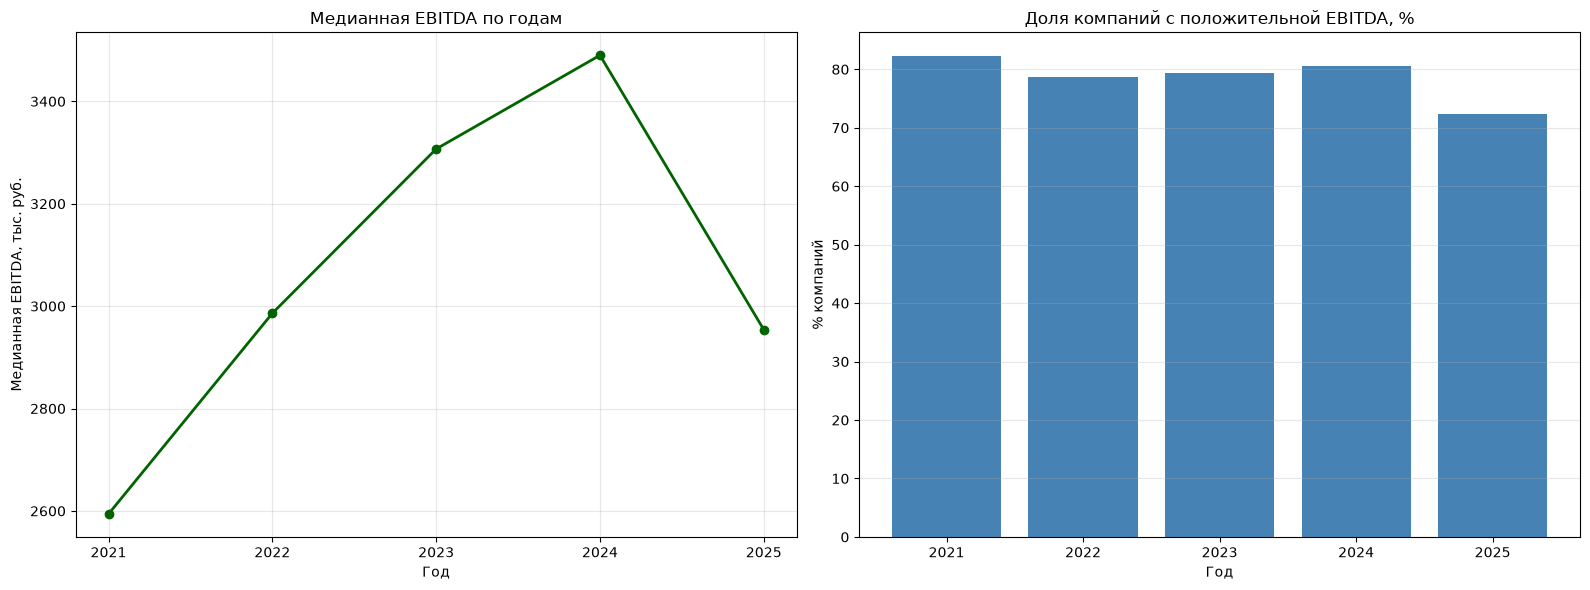

In [15]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].plot(ebitda_by_year.index, ebitda_by_year['median_ebitda'],
             marker='o', color='darkgreen', linewidth=2)
axes[0].set_title('Медианная EBITDA по годам')
axes[0].set_xlabel('Год')
axes[0].set_ylabel('Медианная EBITDA, тыс. руб.')
axes[0].grid(alpha=0.3)

axes[1].bar(ebitda_by_year.index, ebitda_by_year['positive_share'], color='steelblue')
axes[1].set_title('Доля компаний с положительной EBITDA, %')
axes[1].set_xlabel('Год')
axes[1].set_ylabel('% компаний')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('ebitda_dynamics.png', dpi=150)
plt.show()

**Ограничение:** данные за 2025 год неполные — компании обычно подают годовую отчётность с задержкой до конца марта следующего года, поэтому часть компаний ещё не отчиталась за 2025 на момент сбора данных (количество компаний с данными за 2025 год заметно ниже, чем за предыдущие годы). Интерпретировать динамику 2025 года нужно с осторожностью.

## 4. Метрика 2 — распределение роста чистой прибыли

Сравниваем чистую прибыль каждой компании в 2021 и 2024 годах (N = 3 года; оба года полностью закрыты по отчётности, в отличие от неполного 2025-го). Компании с нулевой или отрицательной базой 2021 года исключаются — для них процент роста не имеет содержательного смысла.

In [16]:
profit_2021 = df_financials[df_financials['period'] == '2021'][['inn', 'net_profit']]
profit_2021 = profit_2021.rename(columns={'net_profit': 'profit_2021_val'})

profit_2024 = df_financials[df_financials['period'] == '2024'][['inn', 'net_profit']]
profit_2024 = profit_2024.rename(columns={'net_profit': 'profit_2024_val'})

# Соединяем прибыль 2021 и 2024 годов по ИНН
growth = profit_2021.merge(profit_2024, on='inn', how='inner')
print('После merge:', growth.shape)

# Оставляем только компании с положительной базой 2021 года
# (иначе расчёт % роста будет бессмысленным или сломается делением на 0/отрицательное число)
growth = growth[growth['profit_2021_val'] > 0]
print('После фильтра по положительной базе:', growth.shape)

# Убираем компании, где в 2024 году данных нет вообще (на всякий случай)
growth = growth.dropna(subset=['profit_2021_val', 'profit_2024_val'])
print('После удаления пропусков:', growth.shape)

growth.head()

После merge: (424, 3)
После фильтра по положительной базе: (350, 3)
После удаления пропусков: (345, 3)


,inn,profit_2021_val,profit_2024_val
1,6168028800,4102.0,2872.0
3,3918011080,3513.0,41157.0
4,6673244971,354.0,1825.0
5,7842509070,41.0,-1425.0
7,7814485325,23735.0,88.0


In [17]:
# Процент роста прибыли: (новое - старое) / старое * 100
growth['growth_pct'] = ((growth['profit_2024_val'] - growth['profit_2021_val'])
                         / growth['profit_2021_val']) * 100
growth['growth_pct'] = growth['growth_pct'].round().astype(int)

print(growth[['inn', 'profit_2021_val', 'profit_2024_val', 'growth_pct']].head(10))
print()
print('Статистика по growth_pct:')
print(growth['growth_pct'].describe())

           inn  profit_2021_val  profit_2024_val  growth_pct
1   6168028800           4102.0           2872.0         -30
3   3918011080           3513.0          41157.0        1072
4   6673244971            354.0           1825.0         416
5   7842509070             41.0          -1425.0       -3576
7   7814485325          23735.0             88.0        -100
8   6102062670          69561.0          -8181.0        -112
9   2108002261             18.0           -156.0        -967
10  7728434768          59520.0             54.0        -100
11  0266027709          14870.0         -13684.0        -192
12  7802722839           1143.0              0.0        -100

Статистика по growth_pct:
count       345.000000
mean       -147.414493
std       21547.234472
min     -264360.000000
25%         -93.000000
50%          -8.000000
75%         322.000000
max      172229.000000
Name: growth_pct, dtype: float64


### Гистограмма

Экстремальные выбросы (компании с почти нулевой базой 2021 года дают гигантские проценты роста/падения) обрезаются до диапазона -100%..+200% для читаемости графика — интервалы по 10 п.п., как советует задание на случай проблем с масштабом.

В гистограмму попадёт 195 из 345 компаний


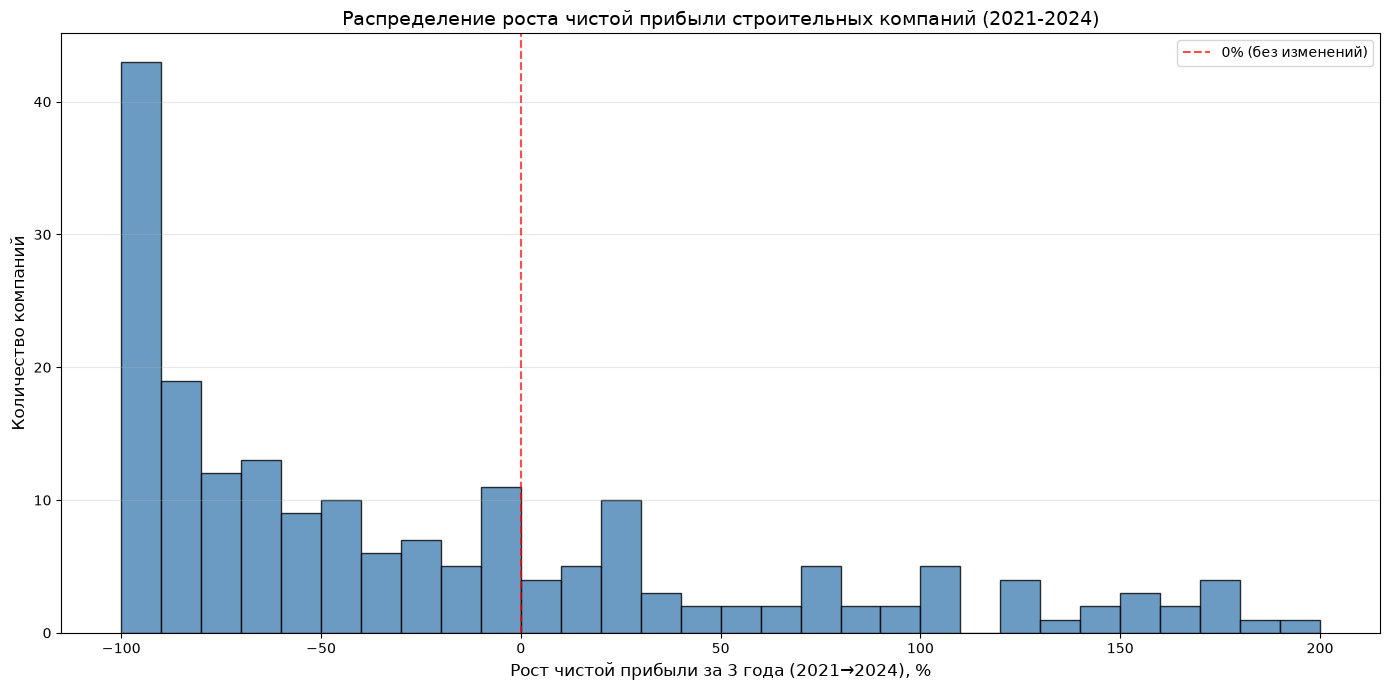

In [18]:
import numpy as np

plot_data = growth[(growth['growth_pct'] >= -100) & (growth['growth_pct'] <= 200)]
print(f'В гистограмму попадёт {len(plot_data)} из {len(growth)} компаний')

bins = np.arange(-100, 210, 10)

fig, ax = plt.subplots(figsize=(14, 7))
ax.hist(plot_data['growth_pct'], bins=bins, color='steelblue', edgecolor='black', alpha=0.8)

ax.set_xlabel('Рост чистой прибыли за 3 года (2021→2024), %', fontsize=12)
ax.set_ylabel('Количество компаний', fontsize=12)
ax.set_title('Распределение роста чистой прибыли строительных компаний (2021-2024)', fontsize=14)
ax.axvline(0, color='red', linestyle='--', alpha=0.7, label='0% (без изменений)')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('growth_histogram.png', dpi=150)
plt.show()

In [19]:
extreme_growth = (growth['growth_pct'] > 200).sum()
extreme_drop = (growth['growth_pct'] < -100).sum()
print('Экстремальный рост (>200%):', extreme_growth)
print('Экстремальное падение (<-100%):', extreme_drop)

Экстремальный рост (>200%): 103
Экстремальное падение (<-100%): 47


## 5. Карта топ-100 компаний по выручке

Берём для каждой компании последний доступный год отчётности (у разных компаний это может быть разный год — 2025 либо более ранний, если 2025 отсутствует), сортируем по выручке, берём топ-100.

In [20]:
df_valid = df_financials[df_financials['revenue'].notna()].copy()
df_valid['period'] = df_valid['period'].astype(int)

latest = df_valid.sort_values('period', ascending=False).drop_duplicates(subset='inn', keep='first')
print(latest.shape)

top100 = latest.sort_values('revenue', ascending=False).head(100).copy()
top100[['inn', 'name', 'period', 'revenue']].head(10)

(495, 7)


,inn,name,period,revenue
851,4004021545,"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""ОРГ-...",2025,11677648.0
1931,7723906368,"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""ВИК""",2025,9768765.0
896,7714468005,"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""СУ-90""",2025,8290111.0
69,4027136246,"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""СТРО...",2025,5475685.0
1832,6442011063,"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""ТАЛИНА""",2025,3848500.0
1184,1639056866,"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""ПРОИ...",2025,3696606.0
1865,4004016390,"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""РВД-3""",2025,3689967.0
2167,6671077940,"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""ЕКАТ...",2025,2634676.0
1794,5260363213,"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""ХАЙ-...",2025,2433636.0
310,5047154277,"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""НОВА...",2025,2412017.0


Подтягиваем регион регистрации из `sample` (в `df_financials` его нет — при парсинге сохранялись только ИНН и название).

In [21]:
top100 = top100.merge(
    sample[['ИНН', 'Регион']],
    left_on='inn', right_on='ИНН', how='left'
)

print(top100.shape)
top100[['inn', 'name', 'Регион', 'revenue']].head()

(100, 9)


,inn,name,Регион,revenue
0,4004021545,"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""ОРГ-...",40 - Калужская область,11677648.0
1,7723906368,"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""ВИК""",50 - Московская область,9768765.0
2,7714468005,"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""СУ-90""",77 - г.Москва,8290111.0
3,4027136246,"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""СТРО...",40 - Калужская область,5475685.0
4,6442011063,"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""ТАЛИНА""",13 - Республика Мордовия,3848500.0


### Настройка сертификатов (для окружений с ошибкой SSL)

На некоторых установках Python (в частности, официальный установщик с python.org на macOS) не хватает корневых сертификатов для HTTPS-запросов вне уже открытой сессии. Явно указываем путь к сертификатам из пакета `certifi`.

In [22]:
!pip3 install --upgrade certifi

import certifi
import os
os.environ['SSL_CERT_FILE'] = certifi.where()

### Геокодирование регионов

Геокодируем только уникальные регионы (а не каждую компанию отдельно) — так намного быстрее, а лимит Nominatim (1 запрос/сек) не позволяет геокодировать все 100 компаний по отдельности за разумное время.

In [23]:
from geopy.geocoders import Nominatim
import time

geolocator = Nominatim(user_agent='startup26_project')

def clean_region_name(region):
    """Убирает код региона в начале строки: '77 - г.Москва' -> 'г.Москва'."""
    if ' - ' in region:
        return region.split(' - ', 1)[1]
    return region

unique_regions = top100['Регион'].unique()
print(f'Уникальных регионов: {len(unique_regions)}')

region_coords = {}

for region in unique_regions:
    clean_name = clean_region_name(region)
    try:
        location = geolocator.geocode(clean_name + ', Россия', timeout=10)
        if location:
            region_coords[region] = (location.latitude, location.longitude)
            print(f'{region} -> {location.latitude:.2f}, {location.longitude:.2f}')
        else:
            print(f'{region} -> НЕ НАЙДЕНО')
        time.sleep(1)  # обязательная пауза — лимит Nominatim, 1 запрос в секунду
    except Exception as e:
        print(f'{region} -> ОШИБКА: {e}')

print('Готово! Найдено координат:', len(region_coords))

Уникальных регионов: 34
40 - Калужская область -> 54.44, 35.53
50 - Московская область -> 55.50, 38.04
77 - г.Москва -> 54.35, 93.92
13 - Республика Мордовия -> 54.44, 44.47
16 - Республика Татарстан (Татарстан) -> 55.79, 49.11
66 - Свердловская область -> 58.64, 61.80
52 - Нижегородская область -> 55.47, 44.09
28 - Амурская область -> 52.80, 128.44
27 - Хабаровский край -> 51.63, 136.12
06 - Республика Ингушетия -> 43.17, 44.98
59 - Пермский край -> 58.60, 56.32
12 - Республика Марий Эл -> 56.58, 47.88
92 - г.Севастополь -> 59.95, 30.48
25 - Приморский край -> 45.08, 134.73
02 - Республика Башкортостан -> 54.47, 55.98
54 - Новосибирская область -> 55.82, 78.87
78 - г.Санкт-Петербург -> 59.94, 30.28
31 - Белгородская область -> 50.71, 37.58
35 - Вологодская область -> 60.04, 43.12
23 - Краснодарский край -> 45.77, 39.03
36 - Воронежская область -> 50.98, 40.15
15 - Республика Северная Осетия - Алания -> 42.99, 44.26
86 - Ханты-Мансийский автономный округ - Югра -> 61.88, 68.64
17 - Рес

Ручные поправки координат для городов федерального значения — Nominatim иногда геокодирует их неточно из-за нестандартного формата названия («г.Москва»).

In [24]:
manual_fixes = {
    '77 - г.Москва': (55.7558, 37.6173),
    '78 - г.Санкт-Петербург': (59.9311, 30.3609),
    '92 - г.Севастополь': (44.6054, 33.5220),
}

for region, coords in manual_fixes.items():
    if region in region_coords:
        region_coords[region] = coords
        print(f'Исправлено: {region} -> {coords}')

print('\nИтоговое число регионов с координатами:', len(region_coords))

Исправлено: 77 - г.Москва -> (55.7558, 37.6173)
Исправлено: 78 - г.Санкт-Петербург -> (59.9311, 30.3609)
Исправлено: 92 - г.Севастополь -> (44.6054, 33.522)

Итоговое число регионов с координатами: 34


In [25]:
!pip3 install geopandas

### Построение карты

Точки компаний размещаются вокруг центра региона со случайным разбросом (jitter), чтобы компании одного региона визуально не сливались в одну точку — точных юридических адресов в реестре нет, только регион. Это допущение стоит держать в уме: карта показывает распределение по регионам, а не точные адреса регистрации. Размер и цвет точки — выручка компании.

Без координат: 0


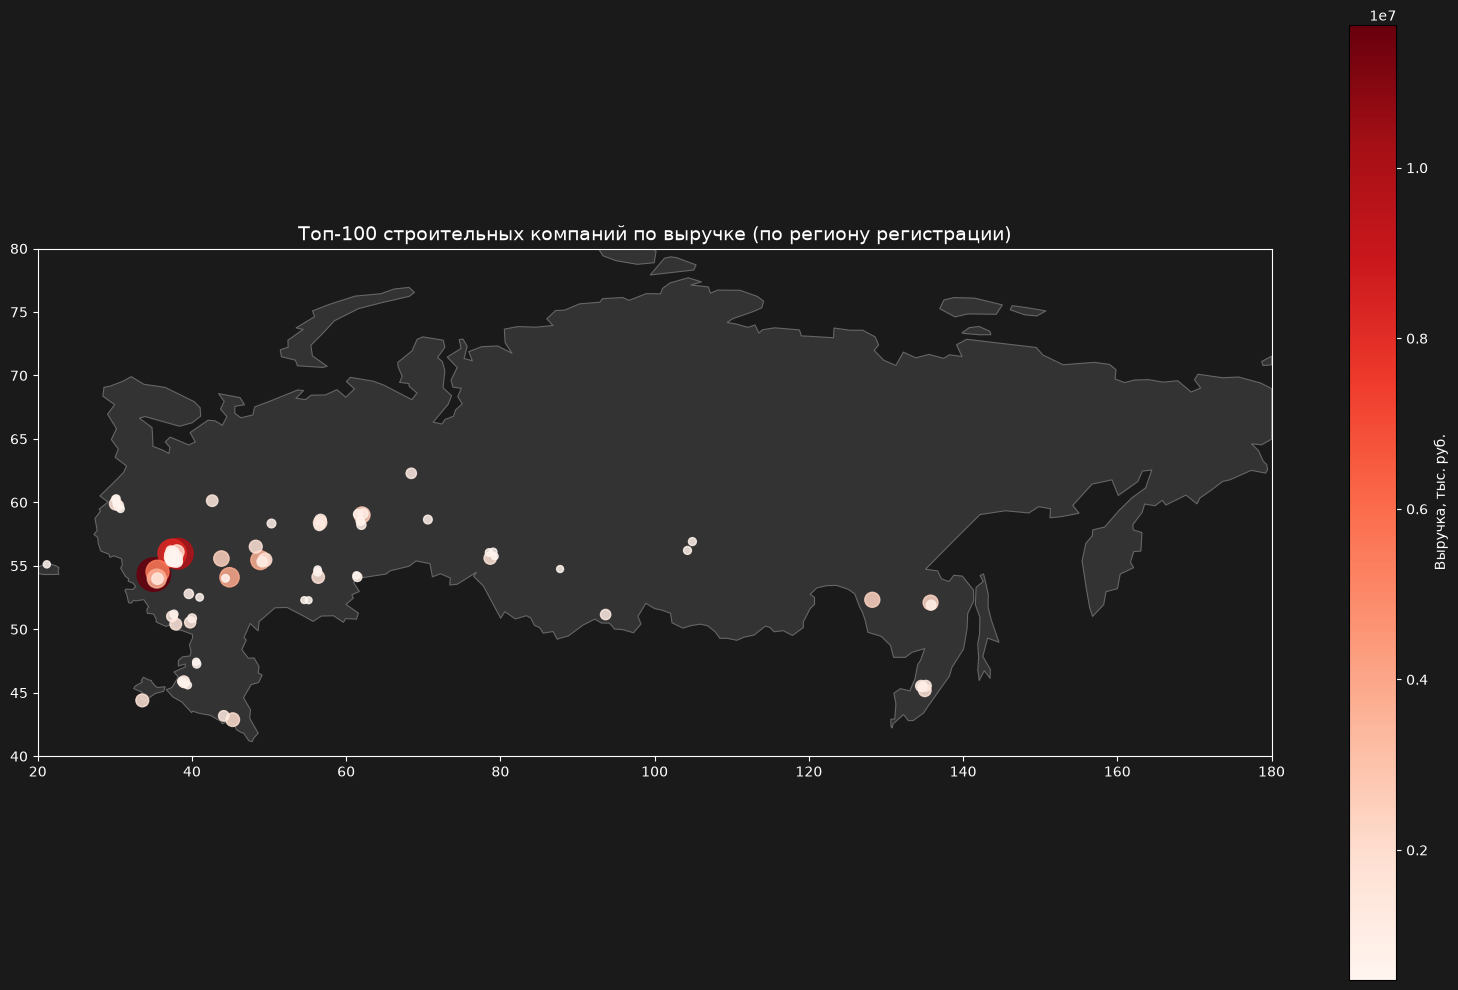

In [26]:
import geopandas as gpd
from shapely.geometry import Point
import numpy as np

# Контур России для фона карты
world = gpd.read_file(
    'https://raw.githubusercontent.com/nvkelso/natural-earth-vector/master/geojson/ne_110m_admin_0_countries.geojson'
)
russia = world[world['NAME'] == 'Russia']

# Координаты компаний по региону
top100['lat'] = top100['Регион'].map(lambda r: region_coords.get(r, (None, None))[0])
top100['lon'] = top100['Регион'].map(lambda r: region_coords.get(r, (None, None))[1])
print('Без координат:', top100['lat'].isna().sum())

# Джиттер, чтобы точки одного региона не накладывались
np.random.seed(42)
jitter_strength = 0.5
top100['lat_jitter'] = top100['lat'] + np.random.uniform(-jitter_strength, jitter_strength, size=len(top100))
top100['lon_jitter'] = top100['lon'] + np.random.uniform(-jitter_strength, jitter_strength, size=len(top100))

geometry = [Point(lon, lat) for lon, lat in zip(top100['lon_jitter'], top100['lat_jitter'])]
gdf = gpd.GeoDataFrame(top100, geometry=geometry, crs='EPSG:4326')

fig, ax = plt.subplots(figsize=(16, 10))
fig.patch.set_facecolor('#1a1a1a')
ax.set_facecolor('#1a1a1a')

russia.plot(ax=ax, color='#333333', edgecolor='#666666', linewidth=0.8)
gdf.plot(ax=ax, column='revenue', cmap='Reds', markersize=gdf['revenue'] / 20000,
         alpha=0.85, legend=True, legend_kwds={'label': 'Выручка, тыс. руб.'})

ax.set_title('Топ-100 строительных компаний по выручке (по региону регистрации)',
             fontsize=14, color='white')
ax.set_xlim(20, 180)
ax.set_ylim(40, 80)
ax.tick_params(colors='white')
for spine in ax.spines.values():
    spine.set_edgecolor('white')

cbar = fig.axes[-1]
cbar.yaxis.label.set_color('white')
cbar.tick_params(colors='white')

plt.tight_layout()
plt.savefig('map_top100.png', dpi=150, facecolor=fig.get_facecolor())
plt.show()

## Вывод

Я проанализировал 500 случайно отобранных малых и средних предприятий отрасли строительства жилых и нежилых зданий (ОКВЭД 41.20) за 2021–2025 годы, собрав финансовую отчётность через bo.nalog.gov.ru для 498 из них (2270 годовых записей).

**Динамика EBITDA.** Медианная EBITDA выросла с 2594 тыс. руб. в 2021 году до 3490 тыс. руб. в 2024-м — устойчивый рост типичной компании на протяжении четырёх лет. При этом доля компаний с положительной EBITDA держится нестабильно в диапазоне 79–82% в 2021–2024 годах, без чёткого тренда роста вместе с медианой. 2025 год интерпретируется отдельно и с осторожностью: медиана и доля прибыльных компаний в нём заметно ниже, но это, вероятно, эффект неполноты данных — компании обычно подают годовую отчётность с задержкой до конца марта следующего года, и на момент сбора данных часть компаний за 2025 год ещё не отчиталась.

**Рост чистой прибыли (2021→2024).** Среди 345 компаний с положительной прибылью в 2021 году медианное изменение к 2024-му составило -8% — типичная компания практически не изменилась, с небольшим уклоном в минус. Распределение при этом сильно неоднородно: 30% компаний (103 из 345) показали рост более чем в 2 раза, а 14% (47 компаний) ушли в глубокий убыток. Экстремальный рост встречается почти вдвое чаще экстремального падения, что говорит о высокой волатильности отрасли на уровне отдельных компаний — устойчивого единого сценария нет, судьба конкретной компании сильно зависит от индивидуальных факторов (выигранные контракты, разовые проекты), а не от общего состояния рынка.

**География.** На карте топ-100 компаний по выручке видна выраженная концентрация вокруг Москвы и Московской области и Санкт-Петербурга — в этих регионах сосредоточено заметно больше крупных компаний выборки, чем в остальных регионах России.

**Итог.** Однозначного ответа «отрасль растёт» или «отрасль падает» дать нельзя. С одной стороны, типичная компания стабильно наращивает EBITDA год к году. С другой — эта стабильность не сопровождается ростом доли прибыльных компаний, а изменение чистой прибыли конкретных компаний крайне неоднородно: почти треть компаний резко растёт, но и заметная часть уходит в убыток. Отрасль скорее находится в состоянии структурной перестройки, чем демонстрирует равномерный подъём или спад — рост сосредоточен у части компаний (в первую очередь у крупных игроков, сконцентрированных в Москве и Санкт-Петербурге), тогда как многие средние и малые компании испытывают нестабильность.

**Ограничения метода:** EBITDA рассчитана упрощённо (без амортизации — этого поля нет в доступных данных формы 2); данные за 2025 год неполны из-за задержки подачи отчётности; на карте показаны координаты центра региона регистрации со случайным разбросом, а не точные юридические адреса компаний, так как в реестре МСП адрес до улицы/дома не указан.